# meta
- learn the concept (what, why)
- from a parent, then going into details.
- For example, serving RMLLM how to make it fast. You have KV cache.
- positional embedding multiple way to do that.
- reinforcement learning you have different policy.
- activation you have different activation, relu, swiglu. Then you answer so why you do that.
- but the important thing is that you know where all this thing fit into the bigger picture.

- learn the code (how)


In [1]:
!pip install torch tokenizers sympy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# chapter 1

- from a untrained model to a reasoning model.
- start from a untrained model you fit in raw tax like from Books or Internet. The model learns the grammar, the language.
- next step is you do a instruction training then the model will be able to follow instructions.
- in the next step, what you do is do you do a preference tuning then the model learns what is a better result? What are people expecting?
- in the final step at least in this book, it is about reasoning model is model model learns how to think, and provide a the reasoning behind the thinking, and produce a better result, especially in logical questions.
- for reasoning model, there are three way to achieve that first is reinforcement learning distillation an inference time scaling
- difference of RLHF and RL


# Chapter 2

In [17]:
from reasoning_from_scratch.qwen3 import download_qwen3_small

# Downloads model weights (~1.5 GB)
download_qwen3_small(kind="base", tokenizer_only=False, out_dir="qwen3")


qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [20]:
# understand tokenizer
from pathlib import Path
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer

tokenizer_path = Path("qwen3") / "tokenizer-base.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)
for i in tokenizer.encode("i like Durian."):
    print(tokenizer.decode([i]))

i
 like
 Dur
ian
.


In [21]:
# load the model
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.qwen3 import Qwen3Model, QWEN_CONFIG_06_B
# Qwen3Model is the pytorch implementation of the model. and QWEN_CONFIG_06_B is the config.
# TODO: learn it.

device = get_device()
model_path = Path("qwen3") / "qwen3-0.6B-base.pth"
model = Qwen3Model(QWEN_CONFIG_06_B)  # model still random weight.
model.load_state_dict(
    torch.load(model_path, map_location="cpu")
)  # load to CPU first
model.to(device)


Using NVIDIA CUDA GPU


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

In [ ]:
# how last token generated
prompt = "Explain large language models."
input_token_ids_list = tokenizer.encode(prompt)
input_tensor = torch.tensor(input_token_ids_list)
input_tensor_fmt = input_tensor.unsqueeze(0).to(device)  # add this
output_tensor = model(input_tensor_fmt)
output_tensor_fmt = output_tensor.squeeze(0)
last = output_tensor_fmt[-1].detach()
tokenizer.decode(last.argmax(dim=-1, keepdim=True).tolist())
# todo: understand the logit.

' Large'

In [ ]:
@torch.inference_mode()
def generate_text_basic(model, token_ids, max_new_tokens, eos_token_id=None):
    input_length = token_ids.shape[1]
    model.eval()
    for _ in range(max_new_tokens):
        out = model(token_ids)[:, -1]
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        if eos_token_id is not None and next_token.item() == eos_token_id:
            break
        token_ids = torch.cat([token_ids, next_token], dim=1)

    return token_ids[:, input_length:]


In [ ]:
prompt = "Explain large language models in a single sentence."
input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt),
    device=device                            #A
    ).unsqueeze(0)
max_new_tokens = 100                        #B
output_token_ids_tensor = generate_text_basic(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=max_new_tokens,
    tokenizer.eos_token_id
)
output_text = tokenizer.decode(
    output_token_ids_tensor.squeeze(0).tolist()     #C
)
print(output_text)

In [ ]:
output_text = tokenizer.decode(
    output_token_ids_tensor.squeeze(0).tolist()  # C
)
print(output_text)

 Large language models are artificial intelligence systems that can understand, generate, and process human language, enabling them to perform a wide range of tasks, from answering questions to writing essays.<|endoftext|>Human language is a complex and dynamic system that has evolved over millions of years to enable effective communication and social interaction. It is composed of a vast array of symbols, including letters, numbers, and words, which are used to convey meaning and express thoughts. The evolution of language has been driven by the need for efficient communication


In [ ]:
import time
from reasoning_from_scratch.ch02 import generate_text_basic_stream

token_ids = torch.tensor(
    [tokenizer.encode("Explain large language models.")]
).to(device)

elapsed_times = []
prev = time.time()
for token in generate_text_basic_stream(
    model, token_ids, max_new_tokens=200, eos_token_id=tokenizer.eos_token_id
):
    now = time.time()
    elapsed_times.append((now - prev) * 1000)  # ms
    prev = now


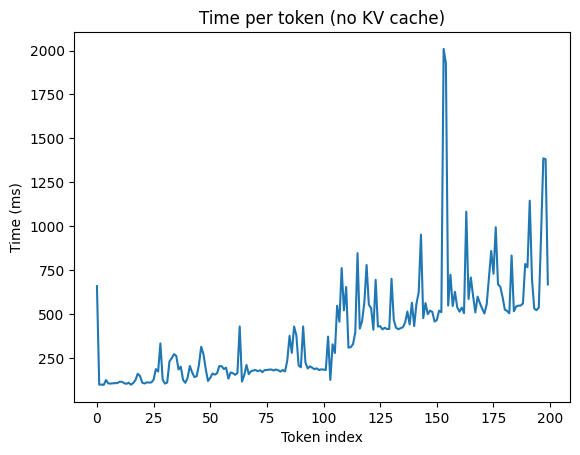

In [ ]:
import matplotlib.pyplot as plt

plt.plot(elapsed_times)
plt.xlabel("Token index")
plt.ylabel("Time (ms)")
plt.title("Time per token (no KV cache)")
plt.show()


## KV cache

In [5]:
from reasoning_from_scratch.qwen3 import KVCache


@torch.inference_mode()
def generate_text_basic_cache(model, prompt, max_new_tokens, eos_token_id=None):
    token_ids = torch.tensor(
        tokenizer.encode(prompt),
        device=device,  # A
    ).unsqueeze(0)
    input_length = token_ids.shape[1]
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])  # A
    model.reset_kv_cache()
    out = model(token_ids, cache=cache)[:, -1]  # B

    for _ in range(max_new_tokens):
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        if eos_token_id is not None and next_token.item() == eos_token_id:
            break

        token_ids = torch.cat([token_ids, next_token], dim=1)
        out = model(next_token, cache=cache)[:, -1]  # C
    output_token_ids_tensor = token_ids[:, input_length:]
    return tokenizer.decode(output_token_ids_tensor.squeeze(0).tolist())

In [7]:
output_text = generate_text_basic_cache(
    model=model, prompt="hello", max_new_tokens=20
)
output_text

', I have a question about the following code. I want to know how to get the value of'

# model compile
todo what does it mean
torch.compile is mainly a CUDA optimization. On MPS, just use the model directly.

In [ ]:
major, minor = map(int, torch.__version__.split(".")[:2])
if (major, minor) >= (2, 8):
    # This avoids retriggering model recompilations
    # in PyTorch 2.8 and newer
    # if the model contains code like self.pos = self.pos + 1
    torch._dynamo.config.allow_unspec_int_on_nn_module = True

model_compiled = torch.compile(model, mode="max-autotune")


AttributeError: partially initialized module 'torch._dynamo' has no attribute 'config' (most likely due to a circular import)

In [ ]:
import torch

print(torch.__version__)
print(torch.backends.mps.is_available())


2.7.1
True


# chapter 3 evaluation
- math verifier
- use regex to parse the answer.
- use sympy to normalize the answer so the comparison is more consistent.

In [ ]:
prompt = (  # A
    r"If $a+b=3$ and $ab=\tfrac{13}{6}$, "
    r"what is the value of $a^2+b^2$?"
)
output_text = generate_text_basic_cache(
    model=model,
    prompt=prompt,
    max_new_tokens=2048,
    eos_token_id=tokenizer.eos_token_id,
)
output_text

' To find the value of \\( a^2 + b^2 \\) given that \\( a + b = 3 \\) and \\( ab = \\frac{13}{6} \\), we can use the following algebraic identity:\n\n\\[\na^2 + b^2 = (a + b)^2 - 2ab\n\\]\n\n**Step 1:** Substitute the given values into the equation.\n\n\\[\na^2 + b^2 = (3)^2 - 2 \\left( \\frac{13}{6} \\right)\n\\]\n\n**Step 2:** Calculate \\( (3)^2 \\).\n\n\\[\n(3)^2 = 9\n\\]\n\n**Step 3:** Calculate \\( 2 \\times \\frac{13}{6} \\).\n\n\\[\n2 \\times \\frac{13}{6} = \\frac{26}{6} = \\frac{13}{3}\n\\]\n\n**Step 4:** Subtract the second result from the first.\n\n\\[\na^2 + b^2 = 9 - \\frac{13}{3}\n\\]\n\n**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.\n\n\\[\n9 = \\frac{27}{3}\n\\]\n\n\\[\na^2 + b^2 = \\frac{27}{3} - \\frac{13}{3} = \\frac{14}{3}\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{\\dfrac{14}{3}}\n\\]'

In [ ]:
from IPython.display import Markdown, display

display(Markdown(output_text))

 To find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [ ]:
from reasoning_from_scratch.ch03 import (
    extract_final_candidate,
    normalize_text,
    sympy_parser,
    equality_check,
)

sympy_parser(normalize_text(extract_final_candidate(output_text)))
print(equality_check(normalize_text("13/4."), normalize_text(r"(13)/(4)")))

True


In [9]:
from reasoning_from_scratch.ch03 import (
    load_math500_test,
    render_prompt,
    evaluate_math500_stream,
)

math_data = load_math500_test()

prompt_prep = render_prompt(prompt)
prompt_prep = "answer this question and provide the answer" + prompt

output_text = generate_text_basic_cache(
    model=model,
    prompt=prompt_prep,
    max_new_tokens=2048,
    eos_token_id=tokenizer.eos_token_id,
)
output_text

NameError: name 'prompt' is not defined

In [ ]:
num_correct, num_examples, acc = evaluate_math500_stream(
    model,
    tokenizer,
    device,
    math_data=math_data[:2],  # A
    max_new_tokens=2048,
    verbose=False,  # B
)

MATH-500: 2/2 | ETA: 00s        
Accuracy: 50.0% (1/2)
Total time: 0.3 min
Average response length: 14.50 tokens
Logs written to: math500-mps.jsonl


In [ ]:
num_correct, num_examples, acc

(1, 2, 0.5)

# chap 4 inference time scaling
question: inference vs training time scaling, which one better.
chain of thought: more time llm generate token, the better the answer.

In [ ]:
from reasoning_from_scratch.ch03 import generate_text_basic_stream_cache
from reasoning_from_scratch.ch04 import generate_text_stream_concat_flex

raw_prompt = "Half the value of $3x-9$ is $x+37$. What is the value of $x$?"
prompt = render_prompt(raw_prompt)
prompt = prompt + "\n\n explain step by step"
print(prompt)

response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=2048,
    verbose=True,
    generate_func=generate_text_basic_stream_cache,
)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:

 explain step by step

To solve the problem, let's break it down step by step.

**Given:**
- Half the value of \( 3x - 9 \) is \( x + 37 \).

**Step 1: Translate the statement into an equation.**
Half the value of \( 3x - 9 \) means \( \frac{1}{2} \times (3x - 9) \). According to the problem, this is equal to \( x + 37 \).

So, the equation is:
\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

**Step 2: Eliminate the fraction by multiplying both sides by 2.**
\[
2 \times \left( \frac{1}{2} \times (3x - 9) \right) = 2 \times (x + 37)
\]
\[
3x - 9 = 2x + 74
\]

**Step 3: Isolate the variable \( x \).**
Subtract \( 2x \) from both sides:
\[
3x - 2x - 9 = 74
\]
\[
x - 9 = 74
\]

**Step 4: Solve for \( x \).**
Add 9 to both sides:
\[
x = 74 + 9
\]
\[
x = 83
\]

**Final Answer:**
\[
\boxed{83}
\]

## self-consistency
Produce samples of answer, same through the most frequent one.

How to generate different kind of token sequence? through temperature scaling and top-p sampling

logits/temperature. t=0 -> argmax. t=1 unchanged.

The torch.multinomial function samples the vocabulary indices proportional to their probabilities.

top-p: only top probablity tokens are sampled.

top-k: top 5 token. 

In [ ]:
from reasoning_from_scratch.ch04 import generate_text_temp_stream_cache

torch.manual_seed(123)
prompt = "the capital of malaysia is "
response = generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=40,
    verbose=True,
    generate_func=generate_text_temp_stream_cache,  # A
    temperature=1,
)

 Kuala Lumpur with 1400killaofwater
Why is the capital of Malaysia called Kuala Lumpur ?
Answer:

Step 1: Identify the key information in the given sentence.
-

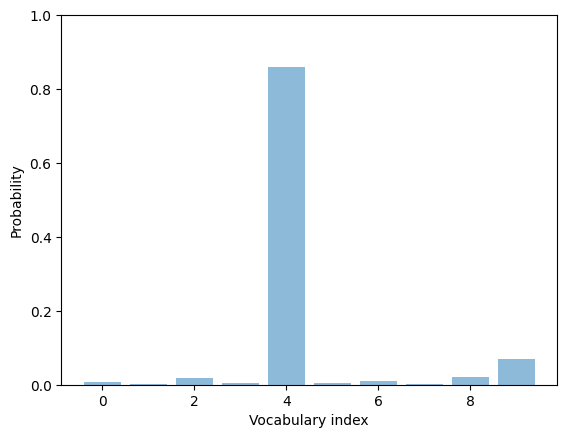

In [ ]:
from reasoning_from_scratch.ch04 import scale_logits_by_temperature

toy_logits = torch.tensor(  # A
    [-0.7, -3.0, 0.1, -1.2, 4.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1)  # B
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)  # C

plt.bar(  # D
    torch.arange(len(toy_probas)), toy_probas, alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

# chap 5 self-refinement
heuristic scorer: shorter and good format.

logprob scorer: calculate joint log probability. log is to rescale small number. (log(p) + log (p2))/2


In [ ]:
@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    logits = model(token_ids.unsqueeze(0)).squeeze(0)  # A
    all_probas = torch.softmax(logits, dim=-1)  # A

    # B
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    next_ids = token_ids[1:]  # C

    next_token_probas = all_probas[t_idx, next_ids]  # D

    print("Next-token probabilities:", [p.item() for p in next_token_probas])
    print(
        "Joint probability:",
        torch.prod(next_token_probas),  # E
    )

# chap 6

sampling = use top_p and temperature to control

reward = 0 if malformat or wrong. 1 correct answer and format.

advantages = (r-r_mean)/(r_sigma + epsilon)

logprobs = sum 
(multiple probs -> small number)

policy gradient loss = pg_loss = −(1/N) Σ (Aᵢ · log P(y⁽ⁱ⁾ | x⁽ⁱ⁾))



In [ ]:
from reasoning_from_scratch.ch03 import (
    load_math500_test,
    render_prompt,
)

math_train = load_math500_test()
math_train[0]

In [42]:
print(render_prompt("a") + "think step by step")

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
a

Answer:think step by step


In [175]:
math_train = load_math500_test()
math_train[0]

{'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$',
 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$',
 'answer': '\\left( 3, \\frac{\\pi}{2} \\right)',
 'subject': 'Precalculus',
 'level': 2,
 'unique_id': 'test/precalculus/807.json'}

In [17]:
from reasoning_from_scratch.ch04 import top_p_filter


def sample_response(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=512,
    temperature=0.8,
    top_p=0.9,
):
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    logits = model(input_ids.unsqueeze(0), cache=cache)[:, -1]

    generated = []

    for _ in range(max_new_tokens):
        logits = logits / temperature
        probas = torch.softmax(logits, dim=-1)
        probas = top_p_filter(probas, top_p)
        next_token = torch.multinomial(probas, num_samples=1)

        token_id = next_token.item()
        generated.append(token_id)

        if (
            tokenizer.eos_token_id is not None
            and token_id == tokenizer.eos_token_id
        ):
            break

        logits = model(next_token, cache=cache)[
            :, -1
        ]  # kv cache, so only next_token

    full_token_ids = torch.cat(
        [
            input_ids,
            torch.tensor(generated, device=device, dtype=input_ids.dtype),
        ]
    )

    return full_token_ids, input_ids.numel(), tokenizer.decode(generated)

In [55]:
prompt = render_prompt(data[0]["problem"])
full_token_ids, dim, decoded = sample_response(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens=20,
    temperature=0.8,
    top_p=0.9,
)


You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\theta),$ where $r > 0$ and $0 \le \theta < 2 \pi.$

Answer:


In [56]:
# print(tokenizer.decode(full_token_ids.tolist()))
print(decoded)
print(len(tokenizer.encode(decoded)))

 $\boxed{(3,\pi)}$<|endoftext|>
9


In [ ]:
# reward
from reasoning_from_scratch.ch03 import extract_final_candidate, grade_answer


def reward_rvlr(answer_text, ground_truth):
    extracted = extract_final_candidate(answer_text, fallback=None)
    if not extracted:
        return 0
    return float(grade_answer(extracted, ground_truth))


print(reward_rvlr("\\boxed{831}", "83"))


0.0


In [ ]:
# logprobs
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]
    return next_token_logps


In [ ]:
avg_logprob_answer(
    model,
    tokenizer,
    "The capital of china is",
    "beijing and shanghai",
    device=device,
)

tensor([-11.1250,  -0.0364,  -3.2812,  -6.5000,  -0.2598], device='mps:0',
       dtype=torch.bfloat16)

In [ ]:
avg_logprob_answer(
    model, tokenizer, "The capital of japan is", "beijing", device=device
)

-7.5

tensor([ -8.8750,  -9.1250,  -8.6875,  ..., -19.2500, -19.2500, -19.2500],
       device='mps:0', dtype=torch.bfloat16, grad_fn=<SelectBackward0>)

In [178]:
from reasoning_from_scratch.ch06 import sequence_logprob


def compute_grpo_loss(
    model,
    tokenizer,
    example,
    device,
    num_rollouts=2,
    max_new_tokens=256,
    temperature=0.8,
    top_p=0.9,
):
    assert num_rollouts >= 2
    roll_logps, roll_rewards, samples = [], [], []
    prompt = render_prompt(example["problem"])
    was_training = model.training
    model.eval()

    for _ in range(num_rollouts):
        token_ids, prompt_len, text = sample_response(
            model,
            tokenizer,
            prompt,
            device,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
        )
        reward = reward_rvlr(text, example["answer"])

        logp = sequence_logprob(model, token_ids, prompt_len)
        roll_logps.append(logp)
        roll_rewards.append(reward)
        samples.append(
            {
                "text": text,
                "reward": reward,
                "gen_len": token_ids.numel() - prompt_len,
            }
        )

    if was_training:
        model.train()

    rewards = torch.tensor(roll_rewards, device=device, dtype=torch.float32)
    advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-4)
    logps = torch.stack(roll_logps)
    pg_loss = -(advantages.detach() * logps).mean()
    loss = pg_loss

    return {
        "loss": loss.item(),
        "pg_loss": pg_loss.item(),
        "rewards": roll_rewards,
        "advantages": advantages.detach().cpu().tolist(),
        "samples": samples,
        "loss_tensor": loss,
    }


In [ ]:
from pprint import pprint

torch.manual_seed(123)
stats = compute_grpo_loss(
    model,
    tokenizer,
    example=math_train[4],
    device=device,
    num_rollouts=2,
    max_new_tokens=2,
    temperature=0.8,
    top_p=0.9,
)
pprint(stats)

{'advantages': [0.0, 0.0],
 'loss': -0.0,
 'loss_tensor': tensor(-0., device='mps:0', grad_fn=<NegBackward0>),
 'pg_loss': -0.0,
 'rewards': [0, 0],
 'samples': [{'gen_len': 2, 'reward': 0, 'text': ' To determine'},
             {'gen_len': 2, 'reward': 0, 'text': ' To determine'}]}


In [24]:
# 6.11 training loop
import time
import torch

from reasoning_from_scratch.ch03 import (
    load_math500_test,
)

from reasoning_from_scratch.ch06 import compute_grpo_loss

math_train = load_math500_test()
math_train[0]


def grpo_train(steps, lr=1e-5, num_rollouts=4, max_new_tokens=256):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    current_step = 0

    try:
        for step in range(steps):
            step_start = time.perf_counter()
            current_step = step + 1
            example = math_train[step % len(math_train)]

            stats = compute_grpo_loss(
                model,
                tokenizer,
                example=example,
                device=device,
                num_rollouts=num_rollouts,
                max_new_tokens=max_new_tokens,
                temperature=0.8,
                top_p=0.9,
            )

            optimizer.zero_grad()
            stats["loss_tensor"].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            reward_avg = torch.tensor(stats["rewards"]).mean().item()
            step_time = time.perf_counter() - step_start
            step_tokens = sum(s["gen_len"] for s in stats["samples"])
            tok_per_sec = step_tokens / step_time if step_time > 0 else 0.0

            print(
                f"[Step {current_step}/{steps}] "
                f"loss={stats['loss']:.4f} "
                f"reward_avg={reward_avg:.3f} "
                f"tok/sec={tok_per_sec:.1f}"
            )

    except KeyboardInterrupt:
        print(f"Stopped at step {current_step}.")

    return model


# Run training -- adjust steps/max_new_tokens as needed
torch.manual_seed(42)
trained_model = grpo_train(
    steps=10, lr=1e-5, num_rollouts=4, max_new_tokens=256
)


[Step 1/10] loss=-4.6847 reward_avg=0.500 tok/sec=18.1
[Step 2/10] loss=-0.0000 reward_avg=0.000 tok/sec=19.0
[Step 3/10] loss=0.3418 reward_avg=0.250 tok/sec=13.5
[Step 4/10] loss=-0.0000 reward_avg=0.000 tok/sec=19.1
[Step 5/10] loss=-0.0000 reward_avg=0.000 tok/sec=18.6
[Step 6/10] loss=-0.0000 reward_avg=0.000 tok/sec=11.4
[Step 7/10] loss=-0.0000 reward_avg=0.000 tok/sec=16.9
[Step 8/10] loss=-0.0000 reward_avg=0.000 tok/sec=18.6
[Step 9/10] loss=-0.0000 reward_avg=0.000 tok/sec=19.3
[Step 10/10] loss=-0.0000 reward_avg=0.000 tok/sec=17.8


In [25]:
# evaluate trained model
from reasoning_from_scratch.ch03 import (
    evaluate_math500_stream,
    load_math500_test,
)

math500 = load_math500_test()

num_correct, num_examples, acc = evaluate_math500_stream(
    model=trained_model,
    tokenizer=tokenizer,
    device=device,
    math_data=math500[
        :50
    ],  # use [:50] for a quick eval, remove slice for full 500
    max_new_tokens=512,
    verbose=True,
)

print(f"Accuracy: {acc:.3f} ({num_correct}/{num_examples})")


 $(3, \frac{\pi}{2})$MATH-500: 1/50 | ETA: 30s         

MATH-500: 1/50 | ETA: 30s         
Extracted: 2
Expected:  \left( 3, \frac{\pi}{2} \right)
Correct so far: 0
--------------------------------------------------
 To find a way to write the double sum \(\sum_{j=1}^\infty \sum_{k=1}^\infty \frac{1}{(j+k)^3}\) in terms of \(p\) and \(q\), we can use the relationship between the sums of the reciprocals of the squares and cubes of the natural numbers.

First, recall the definitions:
\[ p = \sum_{k=1}^\infty \frac{1}{k^2} \]
\[ q = \sum_{k=1}^\infty \frac{1}{k^3} \]

We can express \(p\) and \(q\) in terms of the Riemann zeta function \(\zeta(s)\):
\[ p = \zeta(2) \]
\[ q = \zeta(3) \]

Now, consider the double sum:
\[ \sum_{j=1}^\infty \sum_{k=1}^\infty \frac{1}{(j+k)^3} \]

We can use the identity for the sum of the reciprocals of the cubes of the natural numbers:
\[ \sum_{j=1}^\infty \sum_{k=1}^\infty \frac{1}{(j+k)^3} = \frac{1}{2} \left( \zeta(3) - \zeta(2) \right) \]

This identit

In [28]:
num_correct, num_examples, acc = evaluate_math500_stream(
    model=model,
    tokenizer=tokenizer,
    device=device,
    math_data=math500[
        :50
    ],  # use [:50] for a quick eval, remove slice for full 500
    max_new_tokens=512,
    verbose=True,
)

print(f"Accuracy: {acc:.3f} ({num_correct}/{num_examples})")

 \boxed{(3,\frac{\pi}{2})}MATH-500: 1/50 | ETA: 32s         

MATH-500: 1/50 | ETA: 32s         
Extracted: (3,\frac{\pi}{2})
Expected:  \left( 3, \frac{\pi}{2} \right)
Correct so far: 1
--------------------------------------------------
 \[\boxed{p^2 - 3pq + 2q^2}\]MATH-500: 2/50 | ETA: 36s         

MATH-500: 2/50 | ETA: 36s         
Extracted: p^2 - 3pq + 2q^2
Expected:  p - q
Correct so far: 1
--------------------------------------------------
 \boxed{-\frac{1}{2}}MATH-500: 3/50 | ETA: 31s         

MATH-500: 3/50 | ETA: 31s         
Extracted: -\frac{1}{2}
Expected:  \frac{14}{3}
Correct so far: 1
--------------------------------------------------
 196 has 16 positive whole-number divisors.MATH-500: 4/50 | ETA: 30s         

MATH-500: 4/50 | ETA: 30s         
Extracted: 16
Expected:  9
Correct so far: 1
--------------------------------------------------
 To determine which student has the greatest average speed, we need to calculate the average speed for each student by dividing t

KeyboardInterrupt: 

In [27]:
model.load_state_dict(
    torch.load("qwen3/qwen3-0.6B-base.pth", map_location=device)
)

<All keys matched successfully>

In [4]:
!pwd

/kaggle/working


In [3]:
1 + 1

2

In [ ]:
# entropy sum(-p*logp)
#
# clippedpolicy ratio.
# kl loss term
# format reward

